# Zeitlin model with constraints

This notebook is a demonstration of how to use `quflow.constraints' module

In [1]:
# For non-interactive plots:
%matplotlib inline

# Looks better on macbooks
%config InlineBackend.figure_format = 'retina' 

# Modules to load
import numpy as np
import matplotlib.pyplot as plt
import quflow as qf
from quflow.constraints import *

##### Define the functions defining the islands, the level sets, and the circulations

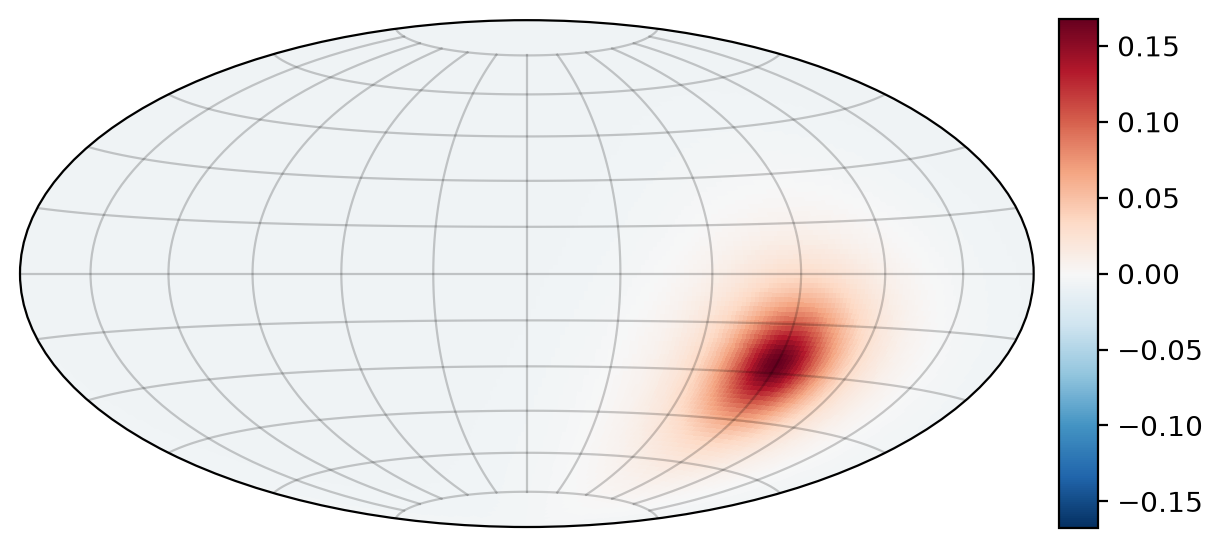

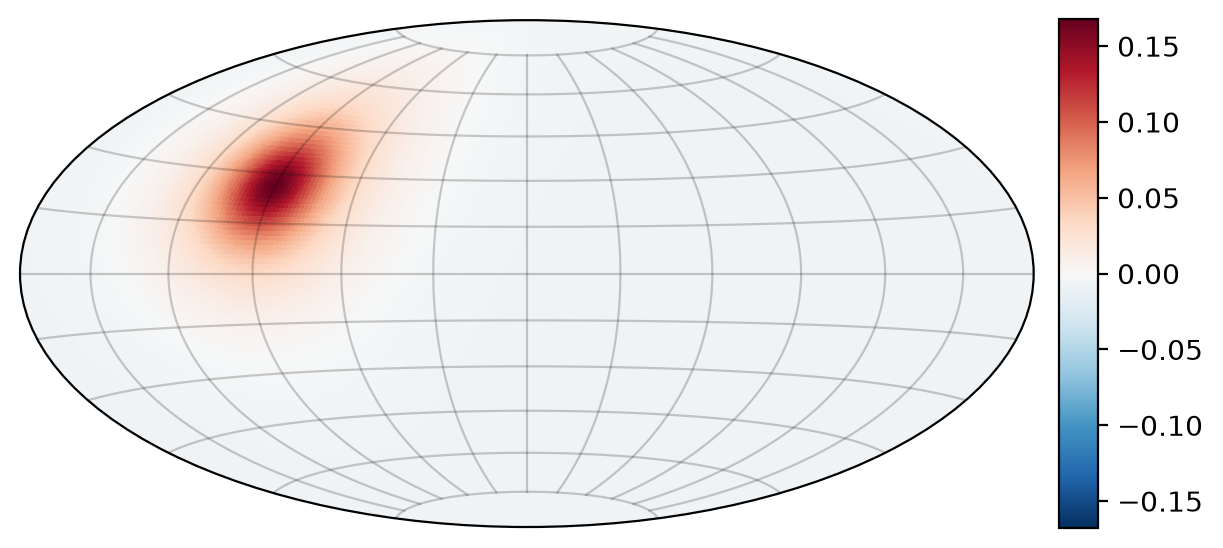

In [2]:
N= 128

f1 = qf.dynamics.blob(N, [0, 2, 1],0.4) # Island 1 
qf.plot(f1, colorbar=True)
f2 = qf.dynamics.blob(N, [0, -2, -1],0.4) # Island 2
qf.plot(f2,colorbar=True)
functions = [f1,f2]
level_sets = [0.0150,0.015]  # Choose coastlines
circulations= [-0,0] # Choose "circulaitons"

##### Make the projection into the space of functions that are zero on each island, except for the circulation term. Then add a plotter for functions in the range.

In [3]:

# Make the projection, which makes the initial vorticity zero on the islands exepct for circulation terms, and sets trace to zero. 
projector = trace_free_block_projector(functions, level_sets, circulations,only_highest=True)
circulations_term = projector(qf.shr2mat(np.zeros(N**2)))
# Make plotter with contours
cplot = plotter(functions, level_sets, circulations_term, N=N)

##### Make some inital vorticity, and project it with the projection.

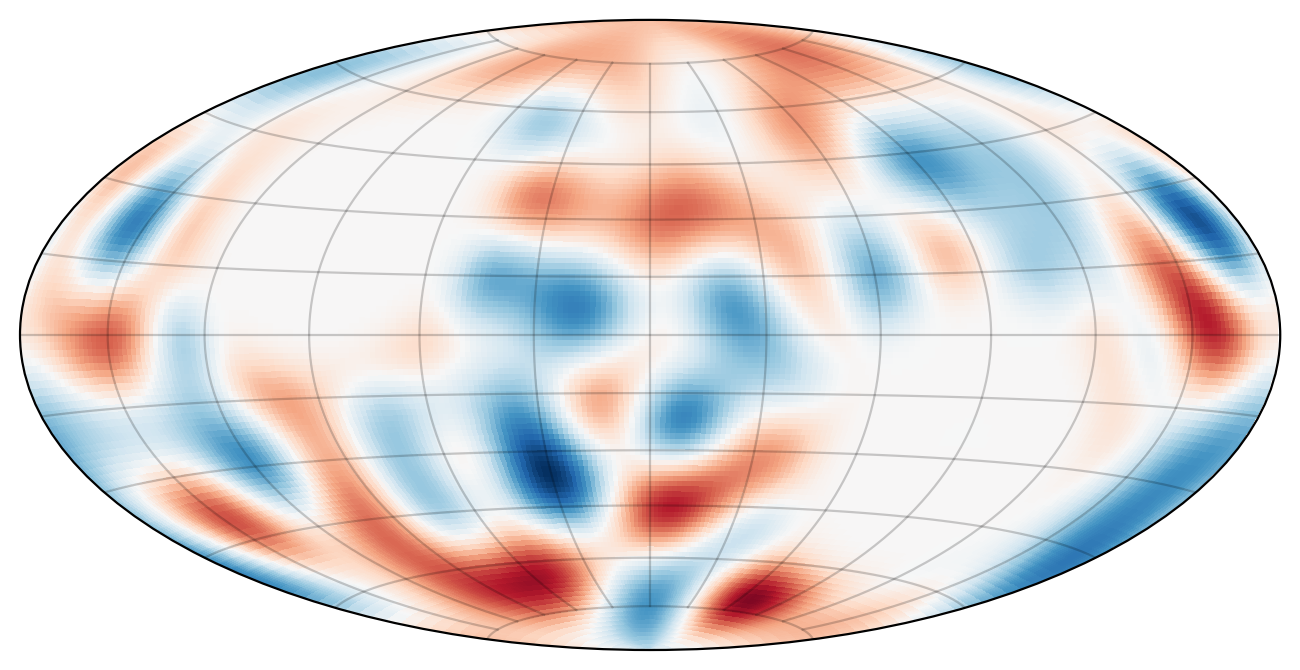

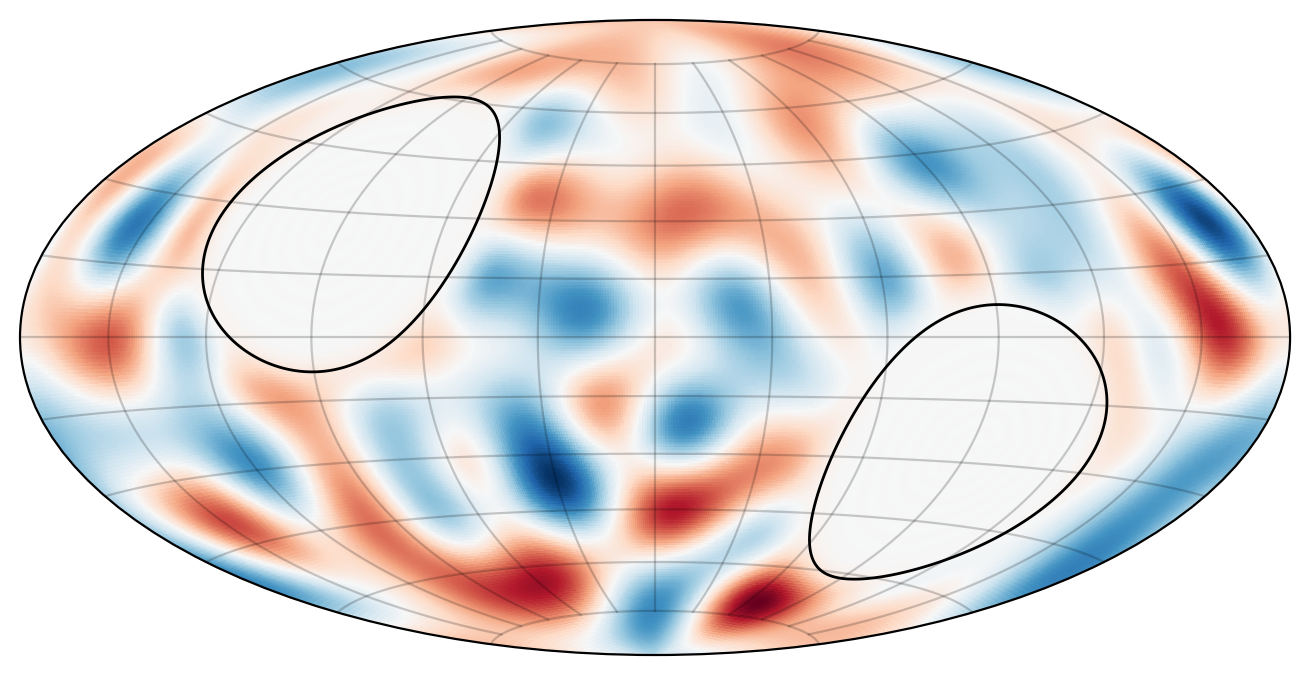

In [4]:
# Make initial data
omega0 = qf.analysis.random_shr(lmax=11, s=0.0, gamma=0., seed=42)
W0 = qf.shr2mat(omega0, N=N) 

# Project the initial vorticity
W0_proj = projector(W0)
qf.plot(W0_proj)
cplot(W0_proj) # Better plot for projected vorticities, and has contours.

##### Make the constraint function $F_c$. 

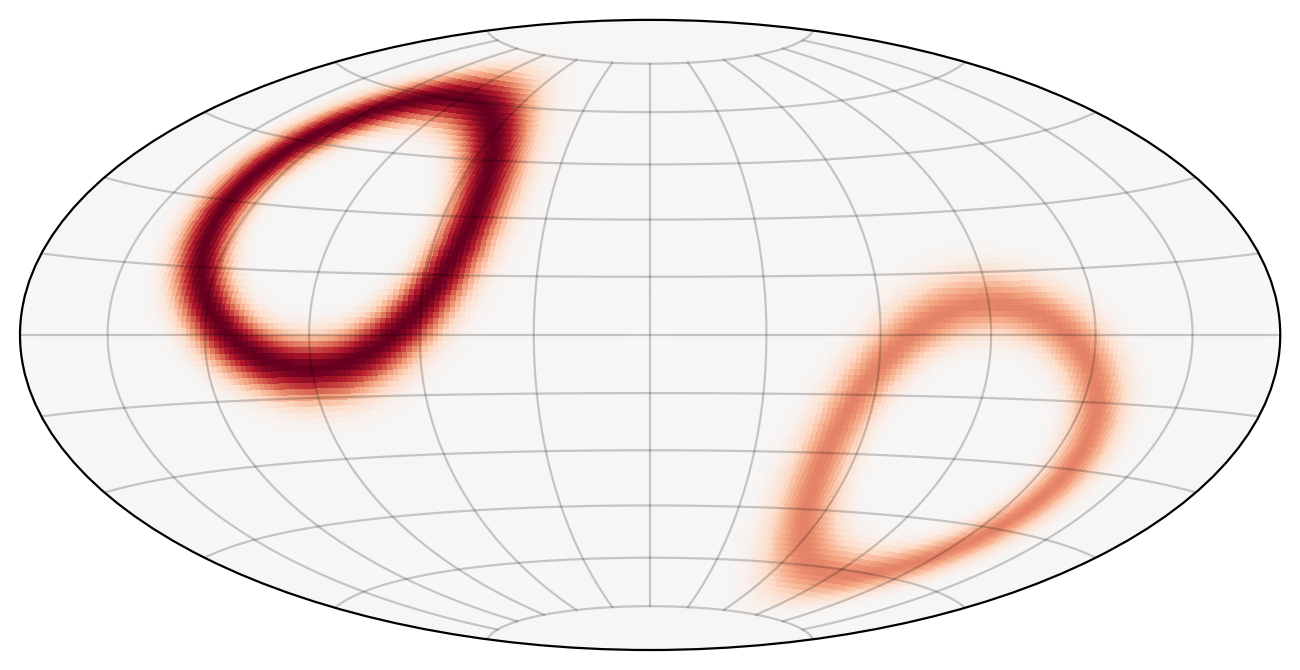

In [5]:
Fc = constraint_matrix(functions,level_sets) # Construct the constraint matrix
qf.plot(Fc)

##### Make the constraint solver

In [6]:
# This can take a long time for large N
constraints_solver = CommutatorPoissonSolver(
  Fc, num_active_eigenvalues = len(functions),  rng=np.random.default_rng(seed=42))

CommutatorPoissonSolver: retained 506 constraint rows.


##### Add logger functions

In [7]:
# For example, define logger functions
# (exactly these loggers are also defined in `qf.physics.energy_euler` and `qf.physics.enstrophy`)
def energy(W):
    P = qf.solve_poisson(W)
    return -qf.geometry.inner_L2(W, P)

def enstrophy(W):
    return qf.geometry.inner_L2(W, W)

# For example, define a new Poisson solver here:
def solve_poisson_special(W):
    raise NotImplementedError()

##### Make simulation object

In [8]:
# Simulation
filename = "constraint_sim_N_{}.hdf5".format(N)
simtime = 10
inner_time = 0.2
dt = 0.25 * qf.hbar(N)

# Callback data object
mysim = qf.QuSimulation(filename, overwrite=True, state=W0_proj, 
                        loggers={'energy':qf.physics.energy_euler, 'enstrophy':qf.physics.enstrophy})

# Set parameters for `solve` function. This is VERY convenient when moving a 
# simulation from your computer to the cluster.
mysim['dt'] = dt
mysim['simtime'] = simtime
mysim['inner_time'] = inner_time
mysim['integrator'] = qf.isomp
#mysim['hamiltonian'] = constraints_solver.solve

##### Run the simulation

  0%|          | 0/2560 [00:00<?, ? steps/s]

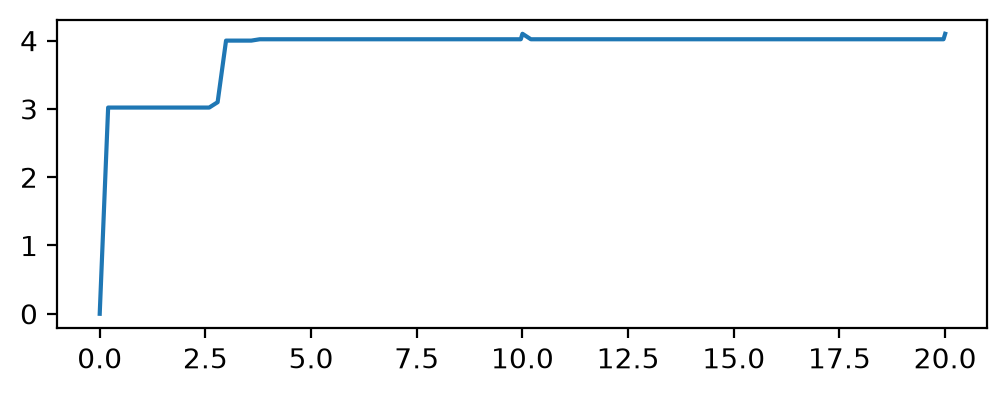

In [13]:
import numba

numba.set_num_threads(1) # Find out what is fastest on your computer

# Run simulation directly from QuSimulation object
qf.solve(mysim,hamiltonian=constraints_solver.solve)

# Plot average number of iterations over time.
# This is a good check that everything went well 
# (you should select the time-step so that you 
# never hit `maxit` which defaults to 10).
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['iterations'])

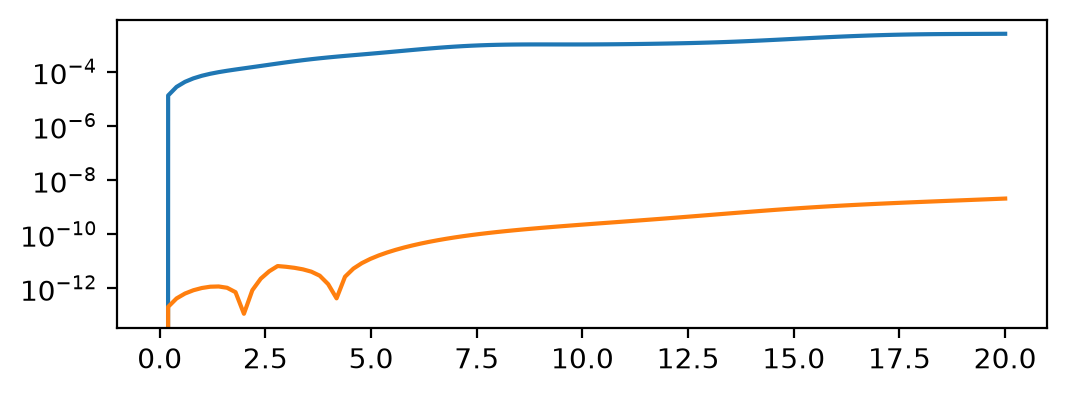

In [17]:
# Plot energy and enstrophy
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    # plt.plot(mysim['time'], mysim['enstrophy'])
    E = mysim['energy']
    Q = mysim['enstrophy']
    t = mysim['time']
    plt.semilogy(t, np.abs(E-E[0]))
    plt.semilogy(t, np.abs(Q-Q[0]))

##### Make video of simulation

In [15]:
from tqdm.auto import tqdm
from IPython.display import Video

animfile = filename.replace(".hdf5", ".mp4")

with qf.QuSimulation(filename) as mysim:
    with qf.Animation(
        animfile,
        N=N,
        plotter=cplot,
    ) as anim:
        for k in tqdm(range(len(mysim["time"]))):
            anim.update(
                mysim["mat", k],
                time=mysim["time", k],
            )


Video(animfile, embed=False)

  0%|          | 0/103 [00:00<?, ?it/s]